## Caclualte the Savage-Dickey ratio between chi_b =0 and chi_b>0
A few KDE bandwidths are considered in the reconstruction of the hyperposterior to get a robust result

In [1]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import corner
from copy import deepcopy
from matplotlib import gridspec
import glob
from tqdm import tqdm
from scipy.stats import dirichlet
import seaborn as sns
from scipy.stats import loguniform
from scipy.stats import gaussian_kde


sys.path.append('../')
import populations.bbh_models as read_models
from populations.utils.bounded_Nd_kde import Bounded_Nd_kde



/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
chi_b = [0.,0.1,0.2,0.5]
alpha = [0.2,0.5,1.,2.,5.]

In [3]:
#corner plots of betas

all_samples = np.array([])

for result_file in glob.glob('/PATH/TO/cont_GWTC3/output*.hdf5'):
    flow_file = h5py.File(result_file, 'r')
    result_samps = np.array(flow_file['model_selection']['samples']['block0_values'])
    all_samples = np.append(all_samples, result_samps)

all_samples = np.reshape(all_samples, (-1, 7))

In [4]:
_labels_dict = {"mchirp": r"$\mathcal{M}$ /$M_{\odot}$", "q": r"$q$", \
"chieff": r"$\chi_{\rm eff}$", "z": r"$z$", "chi00": r"$\chi_\mathrm{b}=0.0$", \
"chi01": r"$\chi_\mathrm{b}=0.1$", "chi02": r"$\chi_\mathrm{b}=0.2$", \
"chi05": r"$\chi_\mathrm{b}=0.5$", "alpha02": r"$\alpha_\mathrm{CE}=0.2$", \
"alpha05": r"$\alpha_\mathrm{CE}=0.5$", "alpha10": r"$\alpha_\mathrm{CE}=1.0$", \
"alpha20": r"$\alpha_\mathrm{CE}=2.0$", "alpha50": r"$\alpha_\mathrm{CE}=5.0$", \
"CE": r"$\texttt{CE}$", "CHE": r"$\texttt{CHE}$", "GC": r"$\texttt{GC}$", \
"NSC": r"$\texttt{NSC}$", "SMT": r"$\texttt{SMT}$", \
"chi_b": r"$\chi_\mathrm{b}$", "alpha_CE": r"$\alpha_\mathrm{CE}$"}

In [4]:
chib_KDE=gaussian_kde(all_samples[:,0], bw_method=0.01)
chib_KDE_bound=Bounded_Nd_kde(all_samples[:,0], bounds=[0.,0.5],bw_method=0.001)
chib_KDE_bound_wide=Bounded_Nd_kde(all_samples[:,0], bounds=[0.,0.5],bw_method=0.1)
chib_pdf = chib_KDE.pdf(np.linspace(0.0,0.1,500))

OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).


In [15]:
chib_KDE_bound_wide=Bounded_Nd_kde(all_samples[:,0], bounds=[0.,0.5],bw_method=0.0005)
chib_pdf_bound_wide = chib_KDE_bound_wide(np.linspace(0.00,0.1,500))

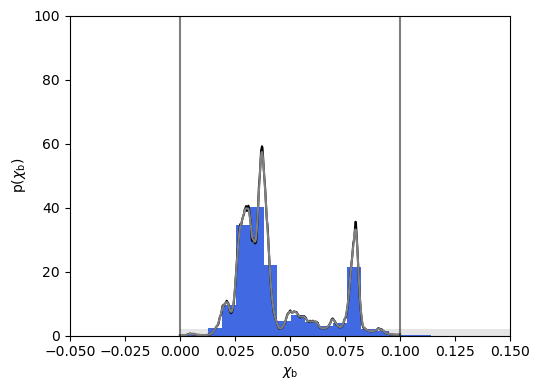

In [75]:
chib_p0 =  np.random.uniform(0, 0.5, size=100000)
plt.rcParams['figure.figsize'] = [5.5, 4]
plt.rcParams["figure.facecolor"]=  (1.0, 0.0, 0.0, 0.0)

plt.hist(all_samples[:,0], density=True, color='royalblue', bins=np.linspace(0,0.5,80))
plt.plot(np.linspace(0.0,0.1,500), chib_pdf, color='black')
plt.plot(np.linspace(0.0,0.1,500), chib_pdf_bound, color='grey')
plt.hist(chib_p0, color='grey', bins=1, alpha=0.2, density=True, zorder=-1000)
plt.vlines(chi_b, 0, 100, color='black', alpha=0.5)
plt.ylim(1e-3,100)
plt.xlim(-0.05,0.15)
plt.autoscale(tight=True, axis='y')
plt.xlabel(_labels_dict['chi_b'])
plt.ylabel('p('+_labels_dict['chi_b']+')')
plt.tick_params(labelsize=10)
#plt.yscale('log')
plt.tight_layout()


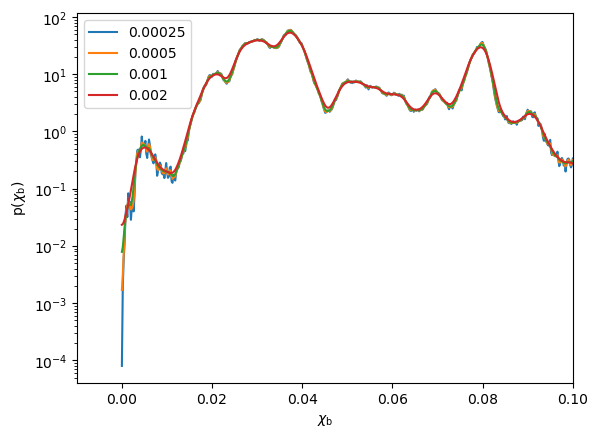

In [36]:
for bw in [0.00025,0.0005,0.001,0.002]:
    chib_KDE_bound_wide=Bounded_Nd_kde(all_samples[:,0], bounds=[0.,0.5],bw_method=bw)
    chib_pdf_bound_wide = chib_KDE_bound_wide(np.linspace(0.00,0.1,500))
    plt.plot(np.linspace(0.,0.1,500), chib_pdf_bound_wide, label=bw)

plt.xlabel(_labels_dict['chi_b'])
plt.ylabel('p('+_labels_dict['chi_b']+')')
plt.tick_params(labelsize=10)
#plt.plot(np.linspace(0.,0.1,500), chib_pdf, color='black')
plt.xlim(-0.01,0.1)
plt.legend()
#plt.ylim(1e-8,100)
plt.yscale('log')

In [25]:
np.log10(chib_KDE_bound(0.0)/2)

array([-2.40587613])

In [26]:
np.log10(chib_KDE_bound_wide(0.0)/2)

array([-3.07138066])

## HPD of chi_b hyperposterior - too multimodal

In [5]:
chib_KDE_bound=Bounded_Nd_kde(all_samples[:,0], bounds=[0.,0.5],bw_method=0.001)
chib_pdf_bound = chib_KDE_bound(np.linspace(0.00,0.5,5000))

OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).


In [6]:
max_post = np.argmax(chib_pdf_bound)
bimode_post = np.argmax(chib_pdf_bound[500:])+500
chi_b = np.linspace(0.00,0.5,5000)
area = 0
i=1

while area < 0.9:
    if max_post-i <0:
        min_idx =0
    else:
        min_idx=max_post-i
    
    min_p = np.min([chib_pdf_bound[min_idx], chib_pdf_bound[max_post+i]])
    upper_pdf = np.zeros_like(chib_pdf_bound)

    for k, val in enumerate(chib_pdf_bound):
        if val > min_p:
            upper_pdf[k] = val

    area=np.trapz(upper_pdf,chi_b)
    i+=1
    chib_min = chi_b[min_idx]
    chib_max = chi_b[bimode_post+i]
    print(area)


0.011479090988424843
0.022920723743857736
0.0342887700972497
0.04554971070548808
0.05667377653389535
0.06763582031961542
0.07841576169015768
0.09418592872154949
0.10445905614086826
0.11451463131721126
0.1243467189959115
0.13394945704977215
0.14331653041689754
0.1524412683464132
0.16563552779817303
0.1741408936796505
0.18239054282970782
0.26957735185078546
0.30798724702967306
0.3486894867540826
0.3772647031277627
0.40840080575204407
0.44172135479705577
0.4677337857191312
0.4836634003052248
0.5054779620746586
0.5268050305411879
0.5418308145708253
0.553754466793182
0.5860762346554076
0.6002020874493708
0.6163560175105274
0.6291661137120063
0.6389681304516585
0.6506408086195744
0.6616849130853348
0.6700943312088281
0.6800047458069897
0.6874878080122097
0.6945569110689371
0.699621464637179
0.706019191138911
0.7134784543271632
0.7190495564141348
0.7230226294854993
0.7280252336939385
0.7304203987711806
0.7349802971878934
0.7486448636430076
0.7607070315473032
0.7721310873754552
0.7802292005837

In [42]:
indcs=np.where(np.roll(upper_pdf,1)!=upper_pdf)[0]
chi_b[indcs][0],chi_b[indcs][-1]

(0.015103020604120825, 0.09301860372074415)

Text(0, 0.5, 'p($\\chi_\\mathrm{b}$)')

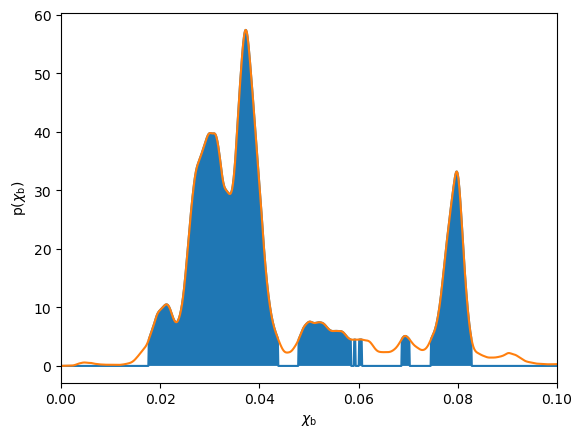

In [7]:
#0.90
plt.plot(chi_b,upper_pdf)
plt.fill_between(chi_b,upper_pdf)
plt.plot(chi_b,chib_pdf_bound)
plt.xlim(0,0.1)
plt.xlabel(_labels_dict['chi_b'])
plt.ylabel('p('+_labels_dict['chi_b']+')')